# La Geometria del Aprendizaje
**Objetivo del bloque**: transformar decisiones de negocio en variables matemáticas
y entender como los algoritmos clasicos las estiman.

El machine learning tiene una intuicion geometrica central:
los datos son puntos en un espacio, y aprender es encontrar la frontera que los separa.

---

**Estructura del notebook:**
1. De decisión a variable objetivo - el paso previo a cualquier algoritmo
2. Tipos de aprendizaje - supervisado, no supervisado, por refuerzo
3. El coste del error - por que la precisión estadistica no es suficiente
4. Como elegir el tipo de ML correcto - tabla de decisión
5. Algoritmos clasicos con Scikit-Learn - demostración práctica
6. Cuando NO usar ML clasico - limites de los algoritmos interpretables

In [1]:
# Crear directorio de exportacion de imagenes
import os
os.makedirs('images', exist_ok=True)
print('[OK] Directorio images/ listo')

[OK] Directorio images/ listo


In [2]:
# Setup
from pathlib import Path
import os

SCRIPTS = Path('..') / 'ejemplos_codigo'
if not SCRIPTS.is_dir():
    raise FileNotFoundError(
        f"No se encuentra '{SCRIPTS.resolve()}'.\n"
        "Ejecuta este notebook desde la carpeta Jupyter_notebooks/"
    )

os.chdir(SCRIPTS)
print(f"[OK] Directorio de scripts: {os.getcwd()}")

%pip install -q scikit-learn matplotlib numpy
%matplotlib inline

[OK] Directorio de scripts: D:\documentos_gdrive\proyectos_claude_mcp\projects\formación_AI_springter\ejemplos_codigo
Note: you may need to restart the kernel to use updated packages.


---
## 1. De Decisión a Variable Objetivo

El primer paso en cualquier proyecto de ML no es elegir un algoritmo.
Es traducir una decisión de negocio a una variable numerica específica.

Esta traducción requiere tres decisiones explicitas:

1. **Tipo de salida**: ¿número continuo, categoria, o sin etiqueta?
2. **Horizonte temporal**: un modelo de churn a 7 dias y a 180 dias son modelos distintos
3. **Definición operativa**: ¿cuando consideramos que un cliente "cancelo"?
   La definición afecta directamente a que datos se usan para entrenar.

**Tabla de referencia para la empresa:**

| Decisión de negocio | Variable objetivo | Tipo |
|---|---|---|
| ¿Este cliente va a cancelar? | P(churn en próximos 90 dias) | Probabilidad 0-1 |
| ¿Cuantas unidades vender? | Unidades vendidas en próximos 7 dias | Regresión |
| ¿Este ticket es urgente? | P(incumplimiento SLA) | Probabilidad 0-1 |
| ¿Que precio ofertar? | Precio recomendado (euros) | Regresión |
| ¿Que clientes son similares? | Grupos naturales en uso del ERP | Clustering |

**La regla**: si no puedes escribir la variable objetivo en una frase,
el problema no esta definido todavia. No elijas el algoritmo antes.

> **Antes de seguir:** ¿puedes pensar en un proceso de tu trabajo donde necesitas predecir o estimar algo, pero todavía no has podido definir exactamente qué número concreto querría producir el modelo?

<details>
<summary>Orientación para el instructor (desplegar tras la reflexión)</summary>

**Una respuesta madura menciona al menos uno de estos elementos:**
- Un proceso con un resultado medible implícito que nunca se ha formalizado (tiempo de respuesta, probabilidad de cierre, riesgo de incumplimiento)
- La dificultad de definir el horizonte temporal: predecir churn "en algún momento" no es lo mismo que en 30 o 90 días
- La diferencia entre lo que se quiere decidir y lo que el modelo puede estimar

**Si nadie responde, preguntar:**
"¿Cuándo alguien de ventas dice 'este cliente va a cancelar', en qué se basa? ¿Ese criterio se podría convertir en un número entre 0 y 1?"

**Señal de comprensión:**
El alumno distingue entre el problema de negocio ("queremos retener clientes") y la variable objetivo que el modelo debe estimar ("probabilidad de cancelación en los próximos 90 días"). Si puede formular la variable en una frase concreta, ha interiorizado el paso clave del bloque.

</details>

In [3]:
# Ejercicio: formalizar una variable objetivo
# Completa los campos con un problema real de tu area

variable_objetivo = {
    "decision_negocio": "¿Este ticket de soporte necesita atencion urgente?",
    "variable_objetivo": "Probabilidad de incumplir el SLA en las proximas 4 horas",
    "tipo_salida": "probabilidad",         # 'probabilidad', 'numero', 'categoria'
    "rango_salida": "0.0 a 1.0",
    "horizonte": "4 horas desde la creacion del ticket",
    "definicion_positivo": "SLA incumplido = tiempo_respuesta > SLA_tipo_ticket",
}

print("DEFINICION DE VARIABLE OBJETIVO")
print("-" * 50)
for k, v in variable_objetivo.items():
    print(f"{k:22s}: {v}")

print()
print("Esta definicion determina:")
print(" - Que columna del ERP es el target de entrenamiento")
print(" - Que ventana de tiempo definen las features")
print(" - Cual es el umbral de decision (prob > 0.3 -> escalar)")

DEFINICION DE VARIABLE OBJETIVO
--------------------------------------------------
decision_negocio      : ¿Este ticket de soporte necesita atencion urgente?
variable_objetivo     : Probabilidad de incumplir el SLA en las proximas 4 horas
tipo_salida           : probabilidad
rango_salida          : 0.0 a 1.0
horizonte             : 4 horas desde la creacion del ticket
definicion_positivo   : SLA incumplido = tiempo_respuesta > SLA_tipo_ticket

Esta definicion determina:
 - Que columna del ERP es el target de entrenamiento
 - Que ventana de tiempo definen las features
 - Cual es el umbral de decision (prob > 0.3 -> escalar)


---
## 2. Tipos de Aprendizaje

### Aprendizaje Supervisado
El mas comun en empresas. Le das al modelo ejemplos con la respuesta correcta.
Dos subtipos:
- **Clasificación**: la salida es una etiqueta (spam/no spam, urgente/normal)
- **Regresión**: la salida es un número (precio, unidades, dias hasta entrega)

### Aprendizaje No Supervisado
No hay respuestas correctas. El modelo encuentra patrones por si solo.
- **Clustering**: agrupa clientes, productos, tickets similares
- **Detección de anomalias**: encuentra comportamientos raros sin etiquetarlos

### Aprendizaje por Refuerzo
El sistema prueba acciones y aprende de las recompensas y penalizaciones.
Esta detras del fine-tuning de los LLMs (RLHF) y de sistemas de optimización dinámica.
Para la empresa: contexto para entender los LLMs, no técnica a implementar directamente.

### Tabla de elección

| ¿Tengo etiquetas? | ¿Quiero predecir...? | Tipo de ML |
|---|---|---|
| Si | Un número | Supervisado, Regresión |
| Si | Una categoria | Supervisado, Clasificación |
| No | Grupos naturales | No supervisado, Clustering |
| No | Casos raros | No supervisado, Anomalias |
| Indiferente | Texto, imagenes, razonamiento | LLMs (Bloque 6) |

---
## 3. El Coste del Error - la métrica que importa

La pregunta que distingue un modelo útil de uno inutil no es
"¿que precisión tiene?" sino **"¿que consecuencias tiene equivocarse y en que dirección?"**

Los modelos de clasificación cometen dos tipos de error:

- **Falso positivo (FP)**: el modelo predice "si" cuando la realidad es "no"
- **Falso negativo (FN)**: el modelo predice "no" cuando la realidad es "si"

Estos dos errores no tienen el mismo coste:

| Problema | Falso Positivo | Falso Negativo | ¿Cual es mas caro? |
|---|---|---|---|
| Churn | Retener a un cliente que no iba a irse | No detectar a un cliente que se va | FN (pierdes el cliente) |
| Fraude | Bloquear una transacción legítima | Aprobar una transacción fraudulenta | FN (perdida económica) |
| Spam | Mover a spam un email importante | Dejar pasar un spam | FP (email perdido) |
| Ticket urgente | Escalar un ticket no urgente | No escalar uno urgente | FN (SLA incumplido) |

**Consecuencia**: el umbral de decisión del modelo no es siempre 0.5.
Si el FN es 10x mas caro que el FP, el umbral optimo es mucho mas bajo.
Esta calibración es una **decisión de negocio**, no matemática.

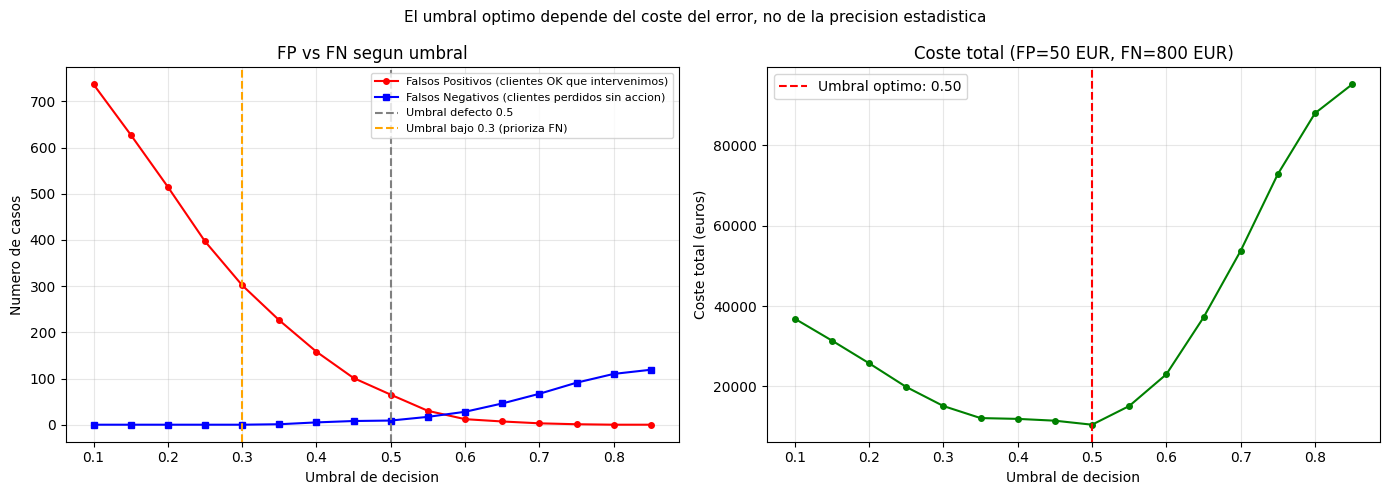

Umbral optimo por coste de negocio: 0.50
(no es 0.5 -  el umbral debe calibrarse con los costes reales de negocio)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simulacion: efecto del umbral de decision sobre FP y FN
# Supongamos un modelo de churn con 1000 clientes

np.random.seed(42)
n_clientes = 1000
tasa_churn_real = 0.15  # 15% de clientes se van realmente

# Generar puntuaciones del modelo (probabilidades predichas)
realidad = np.random.binomial(1, tasa_churn_real, n_clientes)
prob_predicha = np.where(
    realidad == 1,
    np.random.beta(6, 2, n_clientes),  # clientes en churn: prob alta
    np.random.beta(2, 6, n_clientes)   # clientes estables: prob baja
)

# Calcular FP y FN para diferentes umbrales
umbrales = np.arange(0.1, 0.9, 0.05)
fps, fns, precision_list = [], [], []

for umbral in umbrales:
    pred = (prob_predicha >= umbral).astype(int)
    fp = np.sum((pred == 1) & (realidad == 0))
    fn = np.sum((pred == 0) & (realidad == 1))
    tp = np.sum((pred == 1) & (realidad == 1))
    tn = np.sum((pred == 0) & (realidad == 0))
    fps.append(fp)
    fns.append(fn)
    precision_list.append((tp + tn) / n_clientes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(umbrales, fps, 'r-o', label='Falsos Positivos (clientes OK que intervenimos)', markersize=4)
ax1.plot(umbrales, fns, 'b-s', label='Falsos Negativos (clientes perdidos sin accion)', markersize=4)
ax1.axvline(x=0.5, color='gray', linestyle='--', label='Umbral defecto 0.5')
ax1.axvline(x=0.3, color='orange', linestyle='--', label='Umbral bajo 0.3 (prioriza FN)')
ax1.set_xlabel('Umbral de decision')
ax1.set_ylabel('Numero de casos')
ax1.set_title('FP vs FN segun umbral')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Coste total con pesos de negocio
coste_fp = 50   # euros: coste de llamada de retencion innecesaria
coste_fn = 800  # euros: coste de perder un cliente (LTV estimado)
costes_totales = [fp * coste_fp + fn * coste_fn for fp, fn in zip(fps, fns)]

umbral_optimo_idx = np.argmin(costes_totales)
ax2.plot(umbrales, costes_totales, 'g-o', markersize=4)
ax2.axvline(x=umbrales[umbral_optimo_idx], color='red', linestyle='--',
            label=f'Umbral optimo: {umbrales[umbral_optimo_idx]:.2f}')
ax2.set_xlabel('Umbral de decision')
ax2.set_ylabel('Coste total (euros)')
ax2.set_title(f'Coste total (FP={coste_fp} EUR, FN={coste_fn} EUR)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('El umbral optimo depende del coste del error, no de la precision estadistica', fontsize=11)
plt.tight_layout()
plt.savefig('images/B02_fig01.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print(f"Umbral optimo por coste de negocio: {umbrales[umbral_optimo_idx]:.2f}")
print(f"(no es 0.5 - el umbral debe calibrarse con los costes reales de negocio)")

---
## 4. Algoritmos Clasicos - cuando preferirlos a las redes neuronales

Para datos **tabulares** con **volumen moderado**, un modelo clasico interpretable
es casi siempre la primera opción. Las redes neuronales añaden complejidad que
solo se justifica cuando los datos son masivos y la frontera de decisión es muy compleja.

| Algoritmo | Interpretable | Datos necesarios | Frontera de decisión |
|---|---|---|---|
| Regresión lineal/logistica | Alta | Pocos | Lineal |
| Arbol de decisión | Alta | Moderados | Segmentos |
| Random Forest / Gradient Boosting | Media | Moderados | Compleja |
| SVM con kernel RBF | Baja | Moderados | No lineal suave |
| Red Neuronal | Muy baja | Muchos | Arbitrariamente compleja |

Para la empresa en primera instancia:
- **Clasificación de tickets, churn**: Gradient Boosting (XGBoost/LightGBM)
- **Predicción de inventario**: Gradient Boosting o LSTM para series temporales
- **Segmentación de clientes**: K-Means
- **Detección de anomalias en stock**: Isolation Forest

In [5]:
# Algoritmos clasicos con Scikit-Learn:
# Regresion lineal, KNN, SVM, K-Means
# Incluye el metodo del codo para elegir K optimo
%run 08_ml_clasico_sklearn.py

1. REGRESION LINEAL
Coeficientes (pesos): [71.88644879 22.54243658 72.4845378 ]
Intercepto (sesgo):   -0.6364
R2 Score:             0.9850
MSE:                  132.6237

2. K-NEAREST NEIGHBORS (KNN)
K=3: Accuracy = 0.8333
K=5: Accuracy = 0.8167
K=7: Accuracy = 0.8167

3. SUPPORT VECTOR MACHINES (SVM)
Kernel 'linear': Accuracy = 0.8667
Kernel 'rbf': Accuracy = 0.8667
Kernel 'poly': Accuracy = 0.8333

4. K-MEANS CLUSTERING (no supervisado)
Centroides:
[[-2.60516878  8.99280115]
 [-6.85126211 -6.85031833]
 [ 4.68687447  2.01434593]
 [-8.83456141  7.24430734]]
Inercia (suma de distancias al centroide): 203.89
Labels asignados (primeros 20): [3 3 0 1 3 1 2 1 0 2 0 2 0 0 3 0 3 2 0 0]

Metodo del codo:
  K=2: Inercia = 9051.82
  K=3: Inercia = 1773.74
  K=4: Inercia = 203.89
  K=5: Inercia = 184.41
  K=6: Inercia = 165.72
  K=7: Inercia = 148.07



<Figure size 640x480 with 0 Axes>

---
## 5. Experimento: comparación de algoritmos en el mismo dataset

In [6]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Dataset sintetico similar a datos de negocio tabulares
# (features: metricas de uso de cliente, target: churn si/no)
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    random_state=42,
    class_sep=0.8
)

# Comparar algoritmos con validacion cruzada
algoritmos = {
    "Regresion Logistica": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42))
    ]),
    "Arbol de Decision": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
    "SVM (RBF)": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', random_state=42))
    ]),
}

print(f"{'Algoritmo':<25} {'Accuracy media':>15} {'Std':>10}")
print("-" * 55)

resultados = {}
for nombre, modelo in algoritmos.items():
    scores = cross_val_score(modelo, X, y, cv=5, scoring='accuracy')
    resultados[nombre] = scores
    print(f"{nombre:<25} {scores.mean():>14.4f} {scores.std():>10.4f}")

print()
mejor = max(resultados, key=lambda k: resultados[k].mean())
print(f"Mejor en este dataset: {mejor}")
print()
print("Nota: el mejor algoritmo depende del dataset, no es universal.")
print("Para datos tabulares de negocio: Gradient Boosting suele ganar.")
print("Para datos de texto, imagen, codigo: LLMs o arquitecturas especificas.")

Algoritmo                  Accuracy media        Std
-------------------------------------------------------
Regresion Logistica               0.7640     0.0080
Arbol de Decision                 0.7680     0.0214
Random Forest                     0.8560     0.0332
Gradient Boosting                 0.8380     0.0040
SVM (RBF)                         0.8900     0.0179

Mejor en este dataset: SVM (RBF)

Nota: el mejor algoritmo depende del dataset, no es universal.
Para datos tabulares de negocio: Gradient Boosting suele ganar.
Para datos de texto, imagen, codigo: LLMs o arquitecturas especificas.


---
## 7. Ejercicio de Decisión: ¿usarias IA aquí?

### Caso: predecir el cierre de una demo comercial en la empresa

El equipo de ventas quiere predecir si una demo de la empresa terminara en contrato.
Tienen datos históricos de los últimos 2 anos: industria del cliente, número de empleados,
módulos mostrados en la demo, duración de la demo, número de demos previas al cierre,
rol de la persona de contacto (técnico / responsable / directivo).

la empresa cierra unos 40 contratos al ano. Tiene registro de unas 200 demos en total.

---

**Pregunta 1 - La variable objetivo**
¿Que exactamente queremos que el modelo estime? ¿Es un número, una categoria, una probabilidad?
Escribe la variable objetivo en una frase concreta.

**Pregunta 2 - Las variables predictivas**
De las 6 variables disponibles, ¿cuales crees que son mas informativas para predecir el cierre?
¿Alguna podria ser un indicador inverso (cuanto mas alta, menos probable el cierre)?

**Pregunta 3 - La viabilidad del modelo**
Con 200 demos históricas y 40 cierres, ¿crees que hay suficientes datos para entrenar un modelo fiable?
¿Como lo justificarias?

**Pregunta 4 - La decisión final**
¿Usarias IA para esto o lo resolverias con un scoring manual basado en reglas?
Justifica en 3-5 líneas.

---
*Escribe tus respuestas en la celda siguiente.*

### Mis respuestas

**Pregunta 1 - La variable objetivo:**

*(escribe aquí)*

**Pregunta 2 - Las variables predictivas:**

*(escribe aquí)*

**Pregunta 3 - La viabilidad del modelo:**

*(escribe aquí)*

**Pregunta 4 - La decisión final:**

*(escribe aquí)*

---

<!--
CRITERIOS DE Evaluación (para el instructor)

Pregunta 1 - La variable objetivo:
Respuesta correcta: variable binaria (cierra / no cierra) o probabilidad de cierre entre 0 y 1.
También valido: "probabilidad de conversion de demo a contrato".
Insuficiente: "saber si el cliente comprara" (demasiado vago, sin formular como número estimable).
Incorrecto: describir un proceso en lugar de definir una variable.

Pregunta 2 - Las variables predictivas:
Validas: módulos mostrados (senial de ajuste), rol del contacto (nivel de decisión),
número de demos previas (friccion del ciclo), duracion (interes real).
Indicador inverso plausible: número de demos previas (muchas demos = proceso lento = menos probable cierre rápido).
Incompleto: listar todas sin jerarquizar ni razonar la dirección del efecto.

Pregunta 3 - La viabilidad:
Respuesta honesta: 200 casos y 40 positivos es un conjunto muy pequeño para ML fiable.
Riesgo principal: overfitting severo. El modelo aprendera los 40 cierres de memoria.
Alternativa razonable: scoring manual con 3-5 reglas calibradas sobre los datos históricos.
Insuficiente: "si, hay suficientes datos" sin justificacion estadistica.
Incorrecto: ignorar el desequilibrio de clases (200 demos, 40 cierres = 20% positivo).

Pregunta 4 - La decisión:
No hay una única respuesta correcta. Evaluar si el alumno:
 - Menciona el riesgo de poca muestra
 - Propone una alternativa antes de ML (scoring manual)
 - Define una condición de salida (cuantos datos se necesitarian para ML)
 - Evita el sesgo de "usar IA porque existe el dato"
Penalizar: "usaria ML porque tenemos datos y seria mas preciso" sin evaluar el coste de error.
-->


---
## Puntos clave del Bloque 2

1. **Variable objetivo primero**: antes de elegir algoritmo, define que número
   quieres estimar y con que horizonte temporal.

2. **El tipo de salida determina el tipo de modelo**: probabilidad → clasificación,
   número continuo → regresión, sin etiquetas → clustering.

3. **El coste del error es una decisión de negocio**: el umbral de decisión optimo
   no es 0.5, es el que minimiza el coste total de los errores ponderados por su impacto.

4. **Empieza simple**: para datos tabulares, Gradient Boosting supera a la red neuronal
   con menos datos y mas interpretabilidad. Las redes profundas se justifican solo
   cuando el volumen es grande y la frontera de decisión es muy compleja.

---
**Siguiente bloque**: La Red Neuronal como Maquina Geometrica - 
construir una red desde cero para entender que hace exactamente.